In [1]:
from capture_utils_v2 import CaptureSystem

# Initialize the capture system
system = CaptureSystem()


Pixel format set to RGB8
IC4 Grabber and Sink initialized.


4/5 marker corners detected.
[[ 3]
 [10]
 [10]]


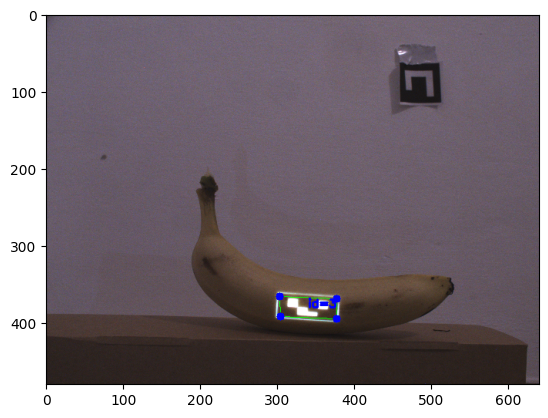

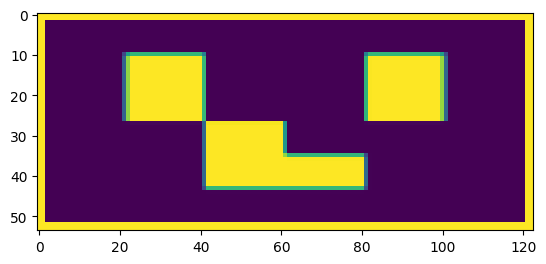

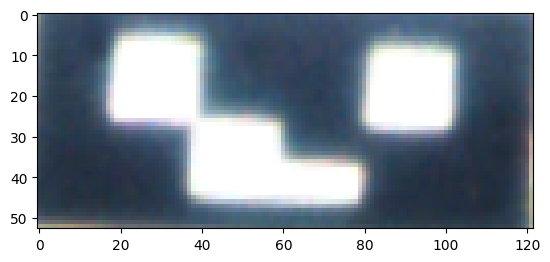

In [2]:
system.display_drawer()
system.run_aruco_detector()


In [3]:
ret = system.photometric_calibration(return_captured=True)
# system.photometric_calibration_adaptive()

100%|██████████| 33/33 [01:01<00:00,  1.85s/it]


In [4]:
# save system orig_proj_corners and corners_img_proj to a file
import pickle
with open("capture_system_state.pkl", "wb") as f:
    pickle.dump({'orig_proj_corners': system.orig_proj_corners,
                  'corners_img_proj': system.corners_img_proj, 
                  'orig_img': system.orig_img, 
                  'img_non_zero_section': system.img_non_zero_section, 
                  'H': system.H
                  }, f)

## Infer

In [1]:
# for capaa
# import sys
# sys.path.append(r'C:\git\CAPAA\src\python')
# from utils import init_prj_window

In [2]:
from capture_utils_v2 import CaptureSystem
import numpy as np
import cv2
import pickle
from aruco_pose import get_camera_angles_from_frame
# Initialize the capture system
system = CaptureSystem()


c:\Users\danny\anaconda3\envs\py310\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Camera Matrix:
[[1.04739831e+03 0.00000000e+00 3.24036999e+02]
 [0.00000000e+00 9.50491793e+02 3.23897832e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients: [ 2.60138074e-01 -4.37871352e+00  3.56370583e-02 -2.58297180e-03
  2.21970709e+01]
Pixel format set to RGB8
IC4 Grabber and Sink initialized.


In [36]:
# im_path = './results/best_patch_ensamble_classifier_16x16_16_2025-12-24_10_08.png'
# im_path = r'C:\git\PhysicalAdverserialProj\results\rejuv_MobileNetV3_16x16_2026-01-18_14_56_top_patches\5_1.0.png'
im_path = r"C:\git\PhysicalAdverserialProj\results\MobileNetV3_16x16_2026-01-20_10_58_top_patches\33_0.86.png"
image_to_project =  cv2.imread(im_path)
image_to_project = cv2.cvtColor(image_to_project, cv2.COLOR_BGR2RGB)

In [37]:
import pickle
# with open("capture_system_state_ablation_base_backup.pkl", "rb") as f:
with open("capture_system_state.pkl", "rb") as f:
    system_dict = pickle.load(f)


system.orig_proj_corners, system.corners_img_proj, system.orig_img, system.img_non_zero_section \
    = system_dict['orig_proj_corners'], system_dict['corners_img_proj'],system_dict['orig_img'], system_dict['img_non_zero_section']

In [38]:
system.plot_on_screen(image_to_project)

In [39]:
#capaa
# from omegaconf import DictConfig, OmegaConf
# import matplotlib as plt
# plt.use('Qt5Agg')
# p = r"C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all\img_0001.png"
# img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
# setup_info = DictConfig(dict(
#     prj_screen_sz      = (1920 , 1080),   # projector screen resolution (i.e., set in the OS)
#     prj_im_sz          = (256 , 256),   # projector input image resolution, the image will be scaled to match the prj_screen_sz by plt
#     prj_offset         = (2560,   0),   # an offset to move the projector plt figure to the correct screen (check your OS display setting)
#     prj_brightness     = 0.5,           # brightness (0~1 float) of the projector gray image for scene illumination.

#     # adjust the two params below according to your ProCams latency, until the projected and captured numbers images are correctly matched
#     delay_frames = 5,  # how many frames to drop before we capture the correct one, increase it when ProCams are not in sync
#     delay_time = 0.1,  # a delay time (s) between the project and capture operations for software sync, increase it when ProCams are not in sync
#     )
# )
# prj = init_prj_window(*setup_info['prj_screen_sz'], 0.5, setup_info['prj_offset'])
# prj.set_data(img)

In [40]:
import torch
# from classfier import predict_raw, weights
# from classfier_ensemble import predict_raw, weights
# from classfier_ensemble_v2 import predict_raw, weights
# from classfier_dino import predict_raw, weights
from classfier_mobilenet import predict_raw, weights


In [41]:
weights.meta['categories'].index('water bottle')

898

In [42]:
forbiden_classes = [898]

In [45]:
from PIL import Image, ImageDraw, ImageFont

def add_text_with_background(img, text, position, font_size=24, text_color=(255, 255, 255), bg_color=(0, 0, 0)):
    """Add text with background using PIL (supports Arial font)"""
    # Convert BGR to RGB for PIL
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    draw = ImageDraw.Draw(pil_img)
    
    # Try to load Arial font, fall back to default if not available
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        try:
            font = ImageFont.truetype("C:/Windows/Fonts/arial.ttf", font_size)
        except:
            font = ImageFont.load_default()
    
    # Get text bounding box
    bbox = draw.textbbox(position, text, font=font)
    padding = 5
    
    # Draw black background rectangle
    draw.rectangle([bbox[0] - padding, bbox[1] - padding, 
                    bbox[2] + padding, bbox[3] + padding], fill=bg_color)
    
    # Draw white text
    draw.text(position, text, font=font, fill=text_color)
    
    # Convert back to BGR for OpenCV
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()
cap = system.cap

caps = []
caps_with_text = []
results = []
raw_predictions = []
for i in range(2400):
    r = cap.read()[1]
    tr = tt(r)
    with torch.no_grad():
        p = predict_raw(tr.unsqueeze(0).cuda())
        res = weights.meta["categories"][p[0].argmax(0).item()]
        prob = p[0].max(0).values.item() * 100
        raw_predictions.append(p)
    
    # add text
    r_orig = r.copy()
    pose_result = get_camera_angles_from_frame(r)
    
    # White text on black background with Arial font
    r = add_text_with_background(r, f'Pred: {res}: {prob:.2f}%', (10, 10), font_size=28)
    
    # Display camera angles if ArUco marker is detected
    # if pose_result['found']:
    # angle = pose_result['angle']
    # dist = pose_result['distance_m']
        # cv2.putText(r, f'H: {angle:.1f}deg  Dist: {dist:.1f}m', (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    # else:
    #     r = add_text_with_background(r, 'ArUco not detected', (10, 50), font_size=22, text_color=(255, 100, 100))
    
    cv2.imshow('frame', r)
    results.append(res)

    caps_with_text.append(r)
    caps.append(r_orig)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        raise

RuntimeError: No active exception to reraise

In [46]:
# save caps to disk

In [47]:
import os
import datetime
cur_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
infer_caps_dir = r"C:\git\PhysicalAdverserialProj\infer_caps_dir"
exp_name = rf"{os.path.basename(im_path).split('.')[0]}"
# exp_name = "capaa_jeep8_5_1"
os.makedirs(f"{infer_caps_dir}/{exp_name}/{cur_time}/")
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/caps.pkl", "wb") as f:
    pickle.dump(caps, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/caps_with_text.pkl", "wb") as f:
    pickle.dump(caps_with_text, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/results.pkl", "wb") as f:
    pickle.dump(results, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/raw_predictions.pkl", "wb") as f:
    pickle.dump(raw_predictions, f)

### With tracking

In [ ]:
from classfier import *
from tracking_utils import TrackerSystem
image_to_project =  patch = cv2.imread(r'C:\git\PhysicalAdverserialProj\results\best_patch_16x16_1_2025-12-13_16_22.png')

tracker = TrackerSystem(system, predict_raw, weights, printed_aruco_id=10)
caps, results = tracker.track_project_and_classify(image_to_project)

In [ ]:
# Tracking and projection using SIFT-based Tracker from C:\git\Tracker
import sys
sys.path.insert(0, r'C:\git\Tracker')

from tracker import Tracker
from tracker.utils import project_bbox_corners

import cv2
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont

# Helper functions
tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

def add_text_with_background(img, text, position, font_size=24, text_color=(255, 255, 255), bg_color=(0, 0, 0)):
    """Add text with background using PIL (supports Arial font)"""
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    draw = ImageDraw.Draw(pil_img)
    try:
        font = ImageFont.truetype("C:/Windows/Fonts/arial.ttf", font_size)
    except:
        font = ImageFont.load_default()
    bbox = draw.textbbox(position, text, font=font)
    padding = 5
    draw.rectangle([bbox[0] - padding, bbox[1] - padding, bbox[2] + padding, bbox[3] + padding], fill=bg_color)
    draw.text(position, text, font=font, fill=text_color)
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

# Load the patch to project
patch = cv2.imread(im_path)
patch = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB)

# Initialize the SIFT-based tracker
tracker = Tracker(
    min_features_threshold=50,
    yolo_model_path="yolo11n.pt",
    sift_nfeatures=0,
    sift_contrast_threshold=0.02,
    sift_edge_threshold=15.0,
    sift_ratio_threshold=0.75,
    homography_ransac_threshold=10.0,
    homography_confidence=0.99,
    homography_max_iters=20000,
    min_inliers=30,
    keyframe_interval=10  # Create keyframe every 10 frames
)

# Initialize projector window
cv2.namedWindow("Projection", cv2.WND_PROP_FULLSCREEN)
cv2.setWindowProperty("Projection", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
cv2.namedWindow("Tracking Preview", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Tracking Preview", 800, 600)

# Get original screen corners and calibration data from system
original_screen_corners = system.orig_proj_corners.astype(np.float32)
original_projected_corners = system.corners_img_proj.astype(np.float32)

# Source corners for perspective transform (patch corners)
src_corners = np.array([
    [0, 0],
    [patch.shape[1], 0],
    [patch.shape[1], patch.shape[0]],
    [0, patch.shape[0]]
], dtype=np.float32)

def render_projection(screen_corners):
    """Render the patch onto the projector at the given screen corners."""
    M = cv2.getPerspectiveTransform(src_corners, screen_corners.astype(np.float32))
    proj_img = cv2.warpPerspective(
        cv2.cvtColor(patch, cv2.COLOR_RGB2BGR), M, 
        (system.screen_res[0], system.screen_res[1])
    )
    cv2.imshow("Projection", proj_img)

# Show initial projection
render_projection(original_screen_corners)

# Capture first frame and initialize tracker
print("Capturing first frame for tracker initialization...")
ret, first_frame = system.cap.read()
first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

# Initialize tracker with YOLO object selection
print("Select the object to track in the popup window...")
if not tracker.initialize(first_frame_rgb, "tracker_init.jpg"):
    print("ERROR: Tracker initialization failed!")
    raise RuntimeError("Tracker initialization failed")

print(f"✓ Tracker initialized with {len(tracker.keyframes[0].keypoints)} features")

# Get initial bbox for reference
initial_bbox = tracker.bboxes[0]
print(f"Initial bbox: {initial_bbox}")

# Store initial relationship between projection and object
# We'll track how the object moves and update projection accordingly
initial_object_center = np.array([
    (initial_bbox[0] + initial_bbox[2]) / 2,
    (initial_bbox[1] + initial_bbox[3]) / 2
])

# Tracking loop with classification
caps = []
caps_with_text = []
results = []
raw_predictions = []

print("\n=== SIFT TRACKER: Tracking and projecting ===")
print("Press 'q' to quit, 'r' to reset")

frame_idx = 1
fps_start = cv2.getTickCount()
fps = 0

try:
    while True:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Track the object using SIFT
        homography = tracker.track_frame(frame_rgb, frame_idx)
        
        if homography is not None:
            # Project the initial bbox corners to current frame
            projected_corners = project_bbox_corners(initial_bbox, homography)
            
            # Compute the transformation for the projection
            # Map the screen space based on object movement
            # Use the homography to transform the projection corners
            new_screen_corners = cv2.perspectiveTransform(
                original_screen_corners.reshape(1, -1, 2), 
                homography
            ).reshape(-1, 2)
            
            # Render the updated projection
            render_projection(new_screen_corners)
            
            # Draw tracking visualization
            frame_viz = frame.copy()
            cv2.polylines(frame_viz, [projected_corners.astype(np.int32)], True, (0, 255, 0), 2)
            status = "Tracking"
            status_color = (0, 255, 0)
        else:
            frame_viz = frame.copy()
            status = "Lost"
            status_color = (0, 0, 255)
            render_projection(original_screen_corners)
        
        # Classification
        with torch.no_grad():
            img_tensor = tt(frame).unsqueeze(0).cuda()
            probs = predict_raw(img_tensor)
            pred_class = weights.meta["categories"][probs[0].argmax().item()]
            pred_prob = probs[0].max().item() * 100
            raw_predictions.append(probs)
        
        # Add text overlay
        frame_viz = add_text_with_background(frame_viz, f'Pred: {pred_class}: {pred_prob:.1f}%', (10, 10), font_size=24)
        frame_viz = add_text_with_background(frame_viz, f'Status: {status} | Frame: {frame_idx}', (10, 50), font_size=18)
        
        # Calculate FPS
        if frame_idx % 30 == 0:
            fps = 30 / ((cv2.getTickCount() - fps_start) / cv2.getTickFrequency())
            fps_start = cv2.getTickCount()
        frame_viz = add_text_with_background(frame_viz, f'FPS: {fps:.1f}', (10, 85), font_size=16)
        
        cv2.imshow("Tracking Preview", frame_viz)
        
        # Store results
        caps.append(frame.copy())
        caps_with_text.append(frame_viz)
        results.append(pred_class)
        
        frame_idx += 1
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            print("Resetting tracker...")
            tracker.keyframes.clear()
            tracker.homographies.clear()
            tracker.bboxes.clear()
            tracker.frame_stats.clear()
            if tracker.initialize(frame_rgb, "tracker_init.jpg"):
                initial_bbox = tracker.bboxes[0]
                print("Tracker reset successful!")
            else:
                print("Tracker reset failed!")

except KeyboardInterrupt:
    print("\nInterrupted by user")

cv2.destroyAllWindows()

print(f"\n✓ Captured {len(caps)} frames")
print(f"  Tracker keyframes created: {len(tracker.keyframes)}")

# Calculate success rate
success_count = sum(1 for p in raw_predictions if p[0].argmax().item() not in forbiden_classes)
success_rate = success_count / len(raw_predictions) * 100 if raw_predictions else 0
print(f"  Attack Success Rate: {success_rate:.1f}% ({success_count}/{len(raw_predictions)} frames)")

## Create GIF

In [ ]:
import imageio

captures = caps
# Create GIF from captures
captures_rgb = [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in captures]
output_gif_path = 'tracked_jeep_16x16_1_2025-12-13_16_22_inception_v3.gif'
imageio.mimsave(output_gif_path, captures_rgb, fps=14, loop=0)
print(f"GIF saved to {output_gif_path} with {len(captures)} frames")

In [ ]:
#

## Create MP4

In [ ]:
im_path

In [ ]:
import cv2
import os
import datetime

# Get frame dimensions from first frame
height, width = caps_with_text[0].shape[:2]
fps = 15  # Adjust as needed

# Create output folder with timestamp
cur_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
exp_name = os.path.basename(im_path).split(".")[0]
output_folder = os.path.join(r"C:\git\PhysicalAdverserialProj\captured_videos", f"{exp_name}_{cur_time}")
os.makedirs(output_folder, exist_ok=True)

# Create output filename in the new folder
output_video_path = os.path.join(output_folder, f'captured_video.mp4')

# Create VideoWriter with mp4v codec
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Write all frames
for frame in caps_with_text:
    out.write(frame)

# Release the writer
out.release()

print(f"✓ Video saved to '{output_video_path}'")
print(f"  - Output folder: {output_folder}")
print(f"  - Frames: {len(caps_with_text)}")
print(f"  - Resolution: {width}x{height}")
print(f"  - FPS: {fps}")
print(f"  - Duration: {len(caps_with_text)/fps:.1f} seconds")

## Post capture analysis

In [ ]:
# Setup for analysis
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import pickle
import importlib

# Import orig_clases - vehicle classes we want to avoid
import consts
importlib.reload(consts)
orig_clases = consts.orig_clases

from aruco_pose import get_camera_angles_from_frame

# Load camera calibration for ArUco detection
cameraMatrix, dist_coeffs = pickle.load(open(r"C:\git\wall_alignment\calibration.pkl", "rb"))

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

print(f"Original vehicle classes to avoid: {orig_clases.tolist()}")
print(f"Number of captured frames: {len(caps)}")

In [ ]:
# Load all classifiers for evaluation
print("Loading classifiers...")

# Ensemble v1 classifier (Inception, ResNet, VGG, ViT, DINOv2)
import classfier_ensemble as ensemble_v1
ensemble_v1_weights = ensemble_v1.weights
print("✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)")

# Ensemble v2 classifier (ConvNeXt, EfficientNet, MobileNet, Swin)
import classfier_ensemble_v2 as ensemble_v2
ensemble_v2_weights = ensemble_v2.weights
print("✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)")

# DINOv2 standalone classifier
import classfier_dino as dino
dino_weights = dino.weights
print("✓ DINOv2 standalone classifier loaded")

categories = ensemble_v1_weights.meta["categories"]
print(f"\n✓ All classifiers ready for evaluation")

In [ ]:
# Analyze all captured frames - extract pose info and classify with all models
results_list = []

for frame_idx, frame in enumerate(tqdm(caps, desc="Analyzing frames")):
    # Get ArUco pose (angle and distance)
    pose_result = get_camera_angles_from_frame(frame)
    
    if not pose_result['found']:
        continue  # Skip frames without ArUco marker
    
    angle = pose_result['angle']
    distance = pose_result['distance_m']
    
    # Prepare image tensor
    img_tensor = tt(frame).unsqueeze(0).cuda()
    
    with torch.no_grad():
        # Get predictions from each model in ensemble v1
        ensemble_v1_per_model = ensemble_v1.predict_raw_per_model(img_tensor)
        
        # Get predictions from each model in ensemble v2
        ensemble_v2_per_model = ensemble_v2.predict_raw_per_model(img_tensor)
        
        # Get DINOv2 standalone prediction
        dino_probs = dino.predict_raw(img_tensor)
    
    # Build result row
    result_row = {
        'frame_idx': frame_idx,
        'angle_deg': angle,
        'distance_m': distance,
    }
    
    # Process ensemble v1 models (individual) - Inception, ResNet, VGG, ViT, DINOv2
    for model_name in ['inception', 'resnet', 'vgg', 'vit', 'dino']:
        if model_name in ensemble_v1_per_model:
            probs = ensemble_v1_per_model[model_name]
            pred_idx = probs[0].argmax().item()
            pred_conf = probs[0][pred_idx].item()
            pred_class = categories[pred_idx]
            
            # Check if attack is successful (prediction NOT in orig_clases)
            is_success = pred_idx not in orig_clases.tolist()
            
            result_row[f'v1_{model_name}_class'] = pred_class
            result_row[f'v1_{model_name}_idx'] = pred_idx
            result_row[f'v1_{model_name}_conf'] = pred_conf
            result_row[f'v1_{model_name}_success'] = is_success
    
    # Ensemble v1 combined prediction
    if 'ensemble' in ensemble_v1_per_model:
        ens_probs = ensemble_v1_per_model['ensemble']
        ens_pred_idx = ens_probs[0].argmax().item()
        ens_pred_conf = ens_probs[0][ens_pred_idx].item()
        ens_pred_class = categories[ens_pred_idx]
        ens_is_success = ens_pred_idx not in orig_clases.tolist()
        
        result_row['v1_combined_class'] = ens_pred_class
        result_row['v1_combined_idx'] = ens_pred_idx
        result_row['v1_combined_conf'] = ens_pred_conf
        result_row['v1_combined_success'] = ens_is_success
    
    # Process ensemble v2 models (individual) - ConvNeXt, EfficientNet, MobileNet, Swin
    for model_name in ['convnext', 'efficientnet', 'mobilenet', 'swin']:
        if model_name in ensemble_v2_per_model:
            probs = ensemble_v2_per_model[model_name]
            pred_idx = probs[0].argmax().item()
            pred_conf = probs[0][pred_idx].item()
            pred_class = categories[pred_idx]
            
            # Check if attack is successful (prediction NOT in orig_clases)
            is_success = pred_idx not in orig_clases.tolist()
            
            result_row[f'v2_{model_name}_class'] = pred_class
            result_row[f'v2_{model_name}_idx'] = pred_idx
            result_row[f'v2_{model_name}_conf'] = pred_conf
            result_row[f'v2_{model_name}_success'] = is_success
    
    # Ensemble v2 combined prediction
    if 'ensemble' in ensemble_v2_per_model:
        ens_probs = ensemble_v2_per_model['ensemble']
        ens_pred_idx = ens_probs[0].argmax().item()
        ens_pred_conf = ens_probs[0][ens_pred_idx].item()
        ens_pred_class = categories[ens_pred_idx]
        ens_is_success = ens_pred_idx not in orig_clases.tolist()
        
        result_row['v2_combined_class'] = ens_pred_class
        result_row['v2_combined_idx'] = ens_pred_idx
        result_row['v2_combined_conf'] = ens_pred_conf
        result_row['v2_combined_success'] = ens_is_success
    
    # DINOv2 standalone
    dino_pred_idx = dino_probs[0].argmax().item()
    dino_pred_conf = dino_probs[0][dino_pred_idx].item()
    dino_pred_class = categories[dino_pred_idx]
    dino_is_success = dino_pred_idx not in orig_clases.tolist()
    
    result_row['dino_standalone_class'] = dino_pred_class
    result_row['dino_standalone_idx'] = dino_pred_idx
    result_row['dino_standalone_conf'] = dino_pred_conf
    result_row['dino_standalone_success'] = dino_is_success
    
    results_list.append(result_row)

print(f"\n✓ Analyzed {len(results_list)} frames with ArUco marker detected")
df = pd.DataFrame(results_list)

In [ ]:
%matplotlib inline

In [ ]:
# Calculate and display success rates per model with clear v1/v2/dino distinction
print("="*80)
print("ATTACK SUCCESS RATE ANALYSIS")
print("="*80)
print(f"\nSuccess = classifier output NOT in orig_clases (vehicle classes)")
print(f"Total frames analyzed: {len(df)}")
print(f"Angle range: {df['angle_deg'].min():.1f}° to {df['angle_deg'].max():.1f}°")
print(f"Distance range: {df['distance_m'].min():.2f}m to {df['distance_m'].max():.2f}m")

# Get all success columns
success_cols = [c for c in df.columns if c.endswith('_success')]

# Define model groups for clear display - DINOv2 standalone only
v1_models = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined']
dino_models = ['dino_standalone']  # Only standalone DINOv2
v2_models = ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin', 'v2_combined']

# Display names mapping
display_names = {
    'v1_inception': 'Inception V3',
    'v1_resnet': 'ResNet18',
    'v1_vgg': 'VGG16',
    'v1_vit': 'ViT-B/16',
    'v1_combined': '*** COMBINED ***',
    'v2_convnext': 'ConvNeXt Base',
    'v2_efficientnet': 'EfficientNet B0',
    'v2_mobilenet': 'MobileNetV3 Large',
    'v2_swin': 'Swin Transformer',
    'v2_combined': '*** COMBINED ***',
    'dino_standalone': 'DINOv2',
}

success_summary = []

def print_model_results(model_list, df, success_summary, group_name):
    for model_name in model_list:
        success_col = f'{model_name}_success'
        if success_col in df.columns:
            success_count = df[success_col].sum()
            total_count = len(df)
            success_rate = success_count / total_count * 100
            
            display = display_names.get(model_name, model_name)
            print(f"  {display:<25} {success_rate:>10.1f}% {success_count:>10} / {total_count:<8}")
            
            success_summary.append({
                'Model': display,
                'Group': group_name,
                'Success Rate (%)': success_rate,
                'Successful Attacks': int(success_count),
                'Total Frames': total_count
            })

# Print Ensemble v1 results
print(f"\n{'─'*80}")
print("ENSEMBLE V1 (Inception V3, ResNet18, VGG16, ViT-B/16)")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(v1_models, df, success_summary, 'V1')

# Print DINOv2 results (standalone only)
print(f"\n{'─'*80}")
print("DINOv2 CLASSIFIER")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(dino_models, df, success_summary, 'DINOv2')

# Print Ensemble v2 results
print(f"\n{'─'*80}")
print("ENSEMBLE V2 (ConvNeXt, EfficientNet, MobileNet, Swin Transformer)")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(v2_models, df, success_summary, 'V2')

success_df = pd.DataFrame(success_summary)
print("\n" + "="*80)

In [ ]:
# Visualize success rate vs angle and distance
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Create angle bins for analysis
angle_bins = np.linspace(df['angle_deg'].min(), df['angle_deg'].max(), 11)
df['angle_bin'] = pd.cut(df['angle_deg'], bins=angle_bins)

# Create distance bins for analysis
distance_bins = np.linspace(df['distance_m'].min(), df['distance_m'].max(), 6)
df['distance_bin'] = pd.cut(df['distance_m'], bins=distance_bins)

# Compute angle_mids once for reuse
angle_success_v1 = df.groupby('angle_bin', observed=False)['v1_combined_success'].agg(['mean', 'count'])
angle_mids = [(b.left + b.right)/2 for b in angle_success_v1.index]

# 1. Overall success rate bar chart
ax = axes[0, 0]
colors = ['green' if r > 50 else 'orange' if r > 25 else 'red' for r in success_df['Success Rate (%)']]
bars = ax.barh(success_df['Model'], success_df['Success Rate (%)'], color=colors)
ax.set_xlabel('Success Rate (%)')
ax.set_title('Attack Success Rate by Model')
ax.set_xlim(0, 100)
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='50% threshold')
for i, (bar, rate) in enumerate(zip(bars, success_df['Success Rate (%)'])):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{rate:.1f}%', va='center')

# 2. Success rate vs Angle (V1 ensemble combined)
ax = axes[0, 1]
angle_success_v1['mean'] = angle_success_v1['mean'] * 100
ax.bar(range(len(angle_mids)), angle_success_v1['mean'], color='steelblue', alpha=0.7)
ax.set_xticks(range(len(angle_mids)))
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('V1 Combined: Success Rate vs Angle')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 3. Success rate vs Distance (V1 ensemble combined)
ax = axes[0, 2]
dist_success = df.groupby('distance_bin', observed=False)['v1_combined_success'].agg(['mean', 'count'])
dist_success['mean'] = dist_success['mean'] * 100
dist_mids = [(b.left + b.right)/2 for b in dist_success.index]
ax.bar(range(len(dist_mids)), dist_success['mean'], color='darkorange', alpha=0.7)
ax.set_xticks(range(len(dist_mids)))
ax.set_xticklabels([f'{d:.2f}m' for d in dist_mids], rotation=45)
ax.set_xlabel('Distance (meters)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('V1 Combined: Success Rate vs Distance')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 4. Scatter plot: Angle vs Distance colored by success (V1 ensemble)
ax = axes[1, 0]
colors_scatter = ['green' if s else 'red' for s in df['v1_combined_success']]
ax.scatter(df['angle_deg'], df['distance_m'], c=colors_scatter, alpha=0.5, s=20)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Distance (meters)')
ax.set_title('V1 Combined: Success Distribution\n(Green=Success, Red=Fail)')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# 5. Success rate vs Angle for DINOv2 standalone
ax = axes[1, 1]
angle_success_dino = df.groupby('angle_bin', observed=False)['dino_standalone_success'].agg(['mean', 'count'])
angle_success_dino['mean'] = angle_success_dino['mean'] * 100
ax.bar(range(len(angle_mids)), angle_success_dino['mean'], color='purple', alpha=0.7)
ax.set_xticks(range(len(angle_mids)))
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('DINOv2 Standalone: Success Rate vs Angle')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 6. Model comparison across angle bins (V1 + V2 + DINOv2)
ax = axes[1, 2]
model_keys = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined', 'v2_combined', 'dino_standalone']
model_display = ['Inception', 'ResNet', 'VGG', 'ViT', 'V1 Comb', 'V2 Comb', 'DINOv2']
x = np.arange(len(angle_mids))
width = 0.11
for i, (key, display) in enumerate(zip(model_keys, model_display)):
    if f'{key}_success' in df.columns:
        model_angle_success = df.groupby('angle_bin', observed=False)[f'{key}_success'].mean() * 100
        ax.bar(x + i*width - width*3, model_angle_success.values, width, label=display, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('All Models: Success Rate vs Angle')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('attack_success_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to 'attack_success_analysis.png'")

In [ ]:
# Detailed breakdown: What classes do models predict when attack succeeds?
print("="*80)
print("ATTACK SUCCESS BREAKDOWN - Top Misclassifications")
print("="*80)

# Define model names based on success columns
success_cols = [c for c in df.columns if c.endswith('_success')]
model_names = [c.replace('_success', '') for c in success_cols]

for model_name, success_col in zip(model_names, success_cols):
    class_col = model_name + '_class'
    if class_col in df.columns:
        # Filter successful attacks only
        successful_df = df[df[success_col] == True]
        
        if len(successful_df) > 0:
            top_misclassifications = successful_df[class_col].value_counts().head(5)
            display_name = model_name.replace('v1_', 'V1: ').replace('v2_', 'V2: ').replace('_', ' ').title()
            
            print(f"\n{display_name} - Successful attacks ({len(successful_df)} frames):")
            print(f"  Top predicted classes (non-vehicle):")
            for cls, count in top_misclassifications.items():
                pct = count / len(successful_df) * 100
                print(f"    - {cls}: {count} ({pct:.1f}%)")

print("\n" + "="*80)

In [ ]:
# Save analysis results to CSV
output_csv = 'attack_success_analysis_results.csv'
df.to_csv(output_csv, index=False)

# Save summary to CSV
summary_csv = 'attack_success_summary.csv'
success_df.to_csv(summary_csv, index=False)

print(f"✓ Detailed results saved to '{output_csv}'")
print(f"✓ Summary saved to '{summary_csv}'")

# Display summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(success_df.to_string(index=False))

In [ ]:
import pandas as pd
results_top = pd.DataFrame(results,columns=['class']).groupby('class').size().sort_values(ascending=False).head(5)

In [55]:
list(results_top.index)

['bubble', 'projector', 'water bottle', 'spotlight', "jack-o'-lantern"]

In [56]:
# Create video with fixed class probability histogram overlay (smoothed)
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.patches import Patch
import os
import datetime
from collections import deque

# Get categories from weights
categories = weights.meta["categories"]

# Fixed classes to show (in order): mailbag, soap dispenser, iron, washbasin, bathtub
# fixed_class_names = ['purse','mailbag','backpack' ,'soap dispenser', 'iron', 'washbasin', 'bathtub']
fixed_class_names = ['water bottle'] + ['bubble', 'projector', 'spotlight', "jack-o'-lantern"]

fixed_indices = []
for name in fixed_class_names:
    try:
        idx = categories.index(name)
        fixed_indices.append(idx)
        print(f"Found '{name}' at index {idx}")
    except ValueError:
        print(f"Warning: '{name}' not found in categories")
        fixed_indices.append(None)

# Video settings
height, width = caps[0].shape[:2]
fps = 15
hist_width = 200  # Width of histogram overlay (halved from 400)
hist_height = 100  # Height of histogram overlay (halved from 200)

# Output path
cur_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
exp_name = os.path.basename(im_path).split(".")[0]
output_folder = os.path.join(r"C:\git\PhysicalAdverserialProj\captured_videos", f"{exp_name}_histogram_{cur_time}")
os.makedirs(output_folder, exist_ok=True)
output_video_path = os.path.join(output_folder, 'captured_video_with_histogram.mp4')

# Create VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Smoothing: exponential moving average
SMOOTHING_ALPHA = 0.3  # Lower = smoother, higher = more responsive
smoothed_probs = None

def create_histogram_overlay(probs_np, class_names, forbidden_classes, fixed_indices, size=(200, 100)):
    """Create a histogram image showing fixed classes"""
    # Get probabilities for fixed classes
    display_probs = [probs_np[idx] if idx is not None else 0.0 for idx in fixed_indices]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(size[0]/100, size[1]/100), dpi=100)
    fig.patch.set_facecolor('black')
    fig.patch.set_alpha(0.7)
    ax.set_facecolor('black')
    
    # Color bars: red for forbidden (vehicle) classes, green for successful attack
    colors = ['#ff4444' if (idx is not None and idx in forbidden_classes) else '#44ff44' for idx in fixed_indices]
    
    # Create horizontal bar chart
    y_pos = np.arange(len(class_names))
    bars = ax.barh(y_pos, [p * 100 for p in display_probs], color=colors, edgecolor='white', linewidth=0.5)
    
    # Add probability text on bars
    for i, (bar, prob) in enumerate(zip(bars, display_probs)):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{prob*100:.1f}%', va='center', ha='left', color='white', fontsize=6, fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(class_names, color='white', fontsize=7)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probability (%)', color='white', fontsize=6)
    ax.tick_params(axis='x', colors='white', labelsize=5)
    ax.set_title('Class Probabilities', color='white', fontsize=8, fontweight='bold')
    
    # Add legend for True class/False class
    legend_elements = [Patch(facecolor='#44ff44', edgecolor='white', label='False class'),
                       Patch(facecolor='#ff4444', edgecolor='white', label='True class')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=5, 
              facecolor='black', edgecolor='white', labelcolor='white')
    
    plt.tight_layout(pad=0.3)
    
    # Convert to image
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    hist_img = np.frombuffer(canvas.tostring_rgb(), dtype=np.uint8)
    hist_img = hist_img.reshape(canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    
    return cv2.cvtColor(hist_img, cv2.COLOR_RGB2BGR)

# Process each frame
print(f"Creating video with histogram overlay...")
print(f"Total frames: {len(caps)}")
print(f"Smoothing alpha: {SMOOTHING_ALPHA} (lower = smoother)")

for frame_idx, (frame, probs) in enumerate(zip(caps, raw_predictions)):
    probs_np = probs[0].cpu().numpy()
    
    # Apply exponential moving average smoothing
    if smoothed_probs is None:
        smoothed_probs = probs_np.copy()
    else:
        smoothed_probs = SMOOTHING_ALPHA * probs_np + (1 - SMOOTHING_ALPHA) * smoothed_probs
    
    # Create histogram overlay with smoothed probabilities
    hist_img = create_histogram_overlay(smoothed_probs, fixed_class_names, forbiden_classes, fixed_indices, size=(hist_width, hist_height))
    
    # Resize histogram to fit
    hist_img = cv2.resize(hist_img, (hist_width, hist_height))
    
    # Overlay histogram on frame (top-left corner)
    frame_with_hist = frame.copy()
    x_offset = 10
    y_offset = 10
    
    # Blend histogram with frame (less opaque: 50% frame + 50% histogram)
    roi = frame_with_hist[y_offset:y_offset+hist_height, x_offset:x_offset+hist_width]
    blended = cv2.addWeighted(roi, 0.5, hist_img, 0.5, 0)
    frame_with_hist[y_offset:y_offset+hist_height, x_offset:x_offset+hist_width] = blended
    
    out.write(frame_with_hist)
    
    if frame_idx % 100 == 0:
        print(f"  Processed {frame_idx}/{len(caps)} frames...")

out.release()

# Calculate overall success rate
success_count = sum(1 for p in raw_predictions if p[0].argmax().item() not in forbiden_classes)
success_rate = success_count / len(raw_predictions) * 100

print(f"\n✓ Video saved to '{output_video_path}'")
print(f"  - Frames: {len(caps)}")
print(f"  - Resolution: {width}x{height}")
print(f"  - FPS: {fps}")
print(f"  - Duration: {len(caps)/fps:.1f} seconds")
print(f"\n  Attack Success Rate: {success_rate:.1f}% ({success_count}/{len(raw_predictions)} frames)")

Found 'water bottle' at index 898
Found 'bubble' at index 971
Found 'projector' at index 745
Found 'spotlight' at index 818
Found 'jack-o'-lantern' at index 607
Creating video with histogram overlay...
Total frames: 623
Smoothing alpha: 0.3 (lower = smoother)
  Processed 0/623 frames...
  Processed 100/623 frames...
  Processed 200/623 frames...
  Processed 300/623 frames...
  Processed 400/623 frames...
  Processed 500/623 frames...
  Processed 600/623 frames...

✓ Video saved to 'C:\git\PhysicalAdverserialProj\captured_videos\33_0_histogram_2026-01-20_19_06\captured_video_with_histogram.mp4'
  - Frames: 623
  - Resolution: 640x480
  - FPS: 15
  - Duration: 41.5 seconds

  Attack Success Rate: 82.0% (511/623 frames)
